# Regression Analysis

This notebook reproduces the regression analyses reported in Section 4.2 of the article.

The purpose is to keep the analysis focused on the three final models used in the paper. 
Additional model specifications are included only where they are needed to document the 
reported robustness checks or to verify the final specification.

All regression models are estimated using OLS with HC3 robust standard errors.


## Load the final user-level analytical database

The user-level database contains one row per enrolled student and combines academic performance,
Kahoot-based course engagement, and AI tutor usage measures.

The variable names below follow the English naming convention used in the publication notebooks.


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.stats.diagnostic import (
    het_breuschpagan,
    het_white,
)
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

users = pd.read_excel("userlevel.xlsx")

print(f"Rows: {len(users)}")
print(f"Unique students: {users['id'].nunique()}")
users.info()


Rows: 140
Unique students: 140
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   140 non-null    object 
 1   T1                   140 non-null    float64
 2   T2                   140 non-null    float64
 3   T3                   140 non-null    float64
 4   T4                   140 non-null    float64
 5   T1234                140 non-null    float64
 6   act_pre              140 non-null    int64  
 7   act_rew              140 non-null    int64  
 8   act_post             140 non-null    int64  
 9   rel_act_pre          140 non-null    float64
 10  rel_act_rew          140 non-null    float64
 11  rel_act_post         140 non-null    float64
 12  rel_act_prerew       140 non-null    float64
 13  rel_act_rewpost      140 non-null    float64
 14  rel_act              140 non-null    float64
 15  T23      

In [2]:
# Reproducibility checks
assert len(users) == 140
assert users["id"].nunique() == 140

expected_profiles = {"non-user", "occasional", "regular"}
assert set(users["profile"].unique()) == expected_profiles

print("Basic data checks passed.")
print(
    users["profile"]
    .value_counts()
    .reindex(["non-user", "occasional", "regular"])
)


Basic data checks passed.
profile
non-user      96
occasional    31
regular       13
Name: count, dtype: int64


## Regression setup

The article reports three OLS models:

1. **Model 1:** T23 performance during the incentivized period, explained by baseline performance (T1),
   pre+incentive course engagement, and AI usage profile.
2. **Model 2:** course engagement across the incentivized and post-incentive periods, explained by T1,
   pre-incentive engagement, and AI usage profile.
3. **Model 3:** final test performance (T4), explained by T23, total course engagement, and the number
   of active AI-use days after the incentive period.

The AI usage measure is intentionally limited to one main RAG-related predictor per model because the
alternative AI usage measures are strongly correlated and including several of them simultaneously
creates multicollinearity and over-specification.


## 1. Model 1 — Test performance during the incentive period

In [3]:
model_1 = smf.ols(
    formula="T23 ~ T1 + rel_act_prerew + C(profile, Treatment('non-user'))",
    data=users,
).fit(cov_type="HC3")

print(model_1.summary())


                            OLS Regression Results                            
Dep. Variable:                    T23   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     56.75
Date:                Sun, 06 Sep 2026   Prob (F-statistic):           5.26e-28
Time:                        22:16:33   Log-Likelihood:                 49.496
No. Observations:                 140   AIC:                            -88.99
Df Residuals:                     135   BIC:                            -74.28
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------

### Model 1: reported result

The final specification reproduces the article's finding that regular AI tutor use is
positively associated with T23 performance after controlling for baseline performance and course engagement,
while the occasional-user coefficient is smaller and not statistically significant.


### Model 1 robustness check

In [ ]:
model_1_questions = smf.ols(
    formula="T23 ~ T1 + rel_act_prerew + rewarded_count",
    data=users,
).fit(cov_type="HC3")

model_1_relevance = smf.ols(
    formula="T23 ~ T1 + rel_act_prerew + avg_rel_rew",
    data=users,
).fit(cov_type="HC3")

print("Alternative RAG specification: total questions in rewarded period")
print(model_1_questions.summary())

print("\nAlternative RAG specification: relevance rate in rewarded period")
print(model_1_relevance.summary())


Alternative RAG specification: total questions
                            OLS Regression Results                            
Dep. Variable:                    T23   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.611
Method:                 Least Squares   F-statistic:                     75.00
Date:                Sun, 06 Sep 2026   Prob (F-statistic):           1.10e-28
Time:                        22:24:30   Log-Likelihood:                 48.293
No. Observations:                 140   AIC:                            -88.59
Df Residuals:                     136   BIC:                            -76.82
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

### Robustness check interpretation

The alternative RAG specifications produced broadly consistent results. While the relevance-rate specification yielded a slightly higher R² and a statistically significant coefficient, the user profile measure was retained for the main specification. This choice reflects the primary analytical focus on differences in AI-use intensity, as the profile variable provides a more direct and interpretable distinction between non-users, occasional users, and regular users. The relevance rate is therefore treated as an alternative operationalization of RAG usage rather than as the primary measure. Importantly, the robustness checks do not alter the overall interpretation of the main model.

## 2. Model 2 — Course engagement across the incentive and post-incentive periods

In [7]:
model_2 = smf.ols(
    formula="rel_act_rewpost ~ rel_act_pre + T1 + C(profile, Treatment('non-user'))",
    data=users,
).fit(cov_type="HC3")

print(model_2.summary())


                            OLS Regression Results                            
Dep. Variable:        rel_act_rewpost   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.571
Method:                 Least Squares   F-statistic:                     68.09
Date:                Sun, 06 Sep 2026   Prob (F-statistic):           1.95e-31
Time:                        22:30:51   Log-Likelihood:                 13.376
No. Observations:                 140   AIC:                            -16.75
Df Residuals:                     135   BIC:                            -2.045
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------

### Model 2: occasional vs. regular users

Test for statistically significant difference between the coefficients of the user profiles


In [8]:
profile_contrast = model_2.t_test(
    "C(profile, Treatment('non-user'))[T.occasional] = "
    "C(profile, Treatment('non-user'))[T.regular]"
)

print(profile_contrast)


                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.0237      0.041      0.580      0.562      -0.056       0.104


### Model 2 robustness check

As an additional specification check, total question volume is used as an alternative measure of AI adoption.


In [9]:
model_2_questions = smf.ols(
    formula="rel_act_rewpost ~ rel_act_pre + T1 + total_questions",
    data=users,
).fit(cov_type="HC3")

print(model_2_questions.summary())


                            OLS Regression Results                            
Dep. Variable:        rel_act_rewpost   R-squared:                       0.500
Model:                            OLS   Adj. R-squared:                  0.489
Method:                 Least Squares   F-statistic:                     57.97
Date:                Sun, 06 Sep 2026   Prob (F-statistic):           3.35e-24
Time:                        22:34:33   Log-Likelihood:                0.57300
No. Observations:                 140   AIC:                             6.854
Df Residuals:                     136   BIC:                             18.62
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0347      0.055     

## 3. Model 3 — Final test performance and voluntary post-incentive AI use

In [10]:
model_3 = smf.ols(
    formula="T4 ~ T23 + rel_act + active_days_post",
    data=users,
).fit(cov_type="HC3")

print(model_3.summary())


                            OLS Regression Results                            
Dep. Variable:                     T4   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     102.3
Date:                Sun, 06 Sep 2026   Prob (F-statistic):           1.06e-34
Time:                        22:35:08   Log-Likelihood:                 1.1830
No. Observations:                 140   AIC:                             5.634
Df Residuals:                     136   BIC:                             17.40
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.0030      0.043  

### Model 3: alternative measure of post-incentive AI use


In [11]:
model_3_questions = smf.ols(
    formula="T4 ~ T23 + rel_act + non_rewarded_count",
    data=users,
).fit(cov_type="HC3")

print(model_3_questions.summary())


                            OLS Regression Results                            
Dep. Variable:                     T4   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     102.4
Date:                Sun, 06 Sep 2026   Prob (F-statistic):           9.90e-35
Time:                        22:36:10   Log-Likelihood:                 1.0176
No. Observations:                 140   AIC:                             5.965
Df Residuals:                     136   BIC:                             17.73
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0012      0

In [12]:
model_3_t1 = smf.ols(
    formula="T4 ~ T1 + rel_act + active_days_post",
    data=users,
).fit(cov_type="HC3")

print(model_3_t1.summary())

                            OLS Regression Results                            
Dep. Variable:                     T4   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     50.80
Date:                Sun, 06 Sep 2026   Prob (F-statistic):           4.32e-22
Time:                        22:37:45   Log-Likelihood:                -9.5267
No. Observations:                 140   AIC:                             27.05
Df Residuals:                     136   BIC:                             38.82
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.0053      0.054  

Replacing T1 with T23 increased the adjusted R² from 0.419 to 0.501 (+0.082), indicating substantially better model fit. Therefore, T23 was retained as the prior-performance control in the final specification.

## Model diagnostics

Standard diagnostic checks were conducted for heteroskedasticity, residual normality, serial correlation, multicollinearity, and linearity. HC3 robust standard errors are used for all three final models.


In [13]:
def diagnostic_summary(model, model_name, predictors):
    bp = het_breuschpagan(model.resid, model.model.exog)
    jb = jarque_bera(model.resid)
    dw = durbin_watson(model.resid)

    X = users[predictors].copy()
    X = pd.get_dummies(X, drop_first=True).astype(float)
    X = sm.add_constant(X)

    vif = pd.DataFrame({
        "Variable": X.columns,
        "VIF": [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ],
    })

    print(f"### {model_name}")
    print(f"Breusch-Pagan p-value: {bp[1]:.4f}")
    print(f"Jarque-Bera p-value: {jb[1]:.4f}")
    print(f"Durbin-Watson: {dw:.3f}")
    print("\nVIF:")
    display(vif.round(3))
    print(f"Condition number: {np.linalg.cond(X):.3f}")
    print()

diagnostic_summary(
    model_1,
    "Model 1",
    ["T1", "rel_act_prerew", "profile"],
)

diagnostic_summary(
    model_2,
    "Model 2",
    ["T1", "rel_act_pre", "profile"],
)

diagnostic_summary(
    model_3,
    "Model 3",
    ["T23", "rel_act", "active_days_post"],
)


### Model 1
Breusch-Pagan p-value: 0.0082
Jarque-Bera p-value: 0.0221
Durbin-Watson: 1.607

VIF:


,Variable,VIF
0,const,7.282
1,T1,1.264
2,rel_act_prerew,1.572
3,profile_occasional,1.267
4,profile_regular,1.158


Condition number: 6.961

### Model 2
Breusch-Pagan p-value: 0.0289
Jarque-Bera p-value: 0.2743
Durbin-Watson: 2.104

VIF:


,Variable,VIF
0,const,7.688
1,T1,1.204
2,rel_act_pre,1.243
3,profile_occasional,1.107
4,profile_regular,1.071


Condition number: 6.129

### Model 3
Breusch-Pagan p-value: 0.5081
Jarque-Bera p-value: 0.0000
Durbin-Watson: 1.979

VIF:


,Variable,VIF
0,const,6.195
1,T23,1.352
2,rel_act,1.403
3,active_days_post,1.046


Condition number: 6.644



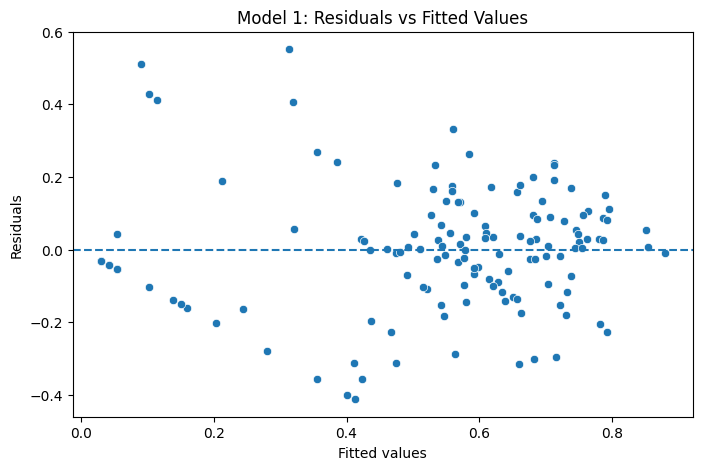

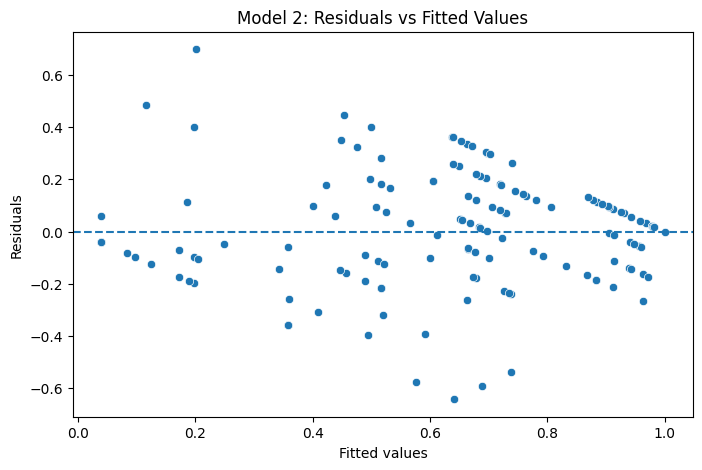

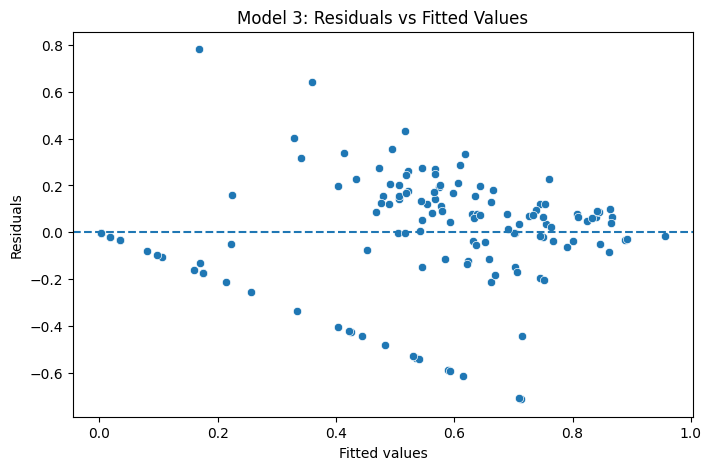

In [15]:
# Residuals vs Fitted Plots

import matplotlib.pyplot as plt
import seaborn as sns


def residuals_vs_fitted(model, title):
    plt.figure(figsize=(8, 5))
    
    sns.scatterplot(
        x=model.fittedvalues,
        y=model.resid
    )
    
    plt.axhline(0, linestyle='--')
    
    plt.xlabel('Fitted values')
    plt.ylabel('Residuals')
    plt.title(title)
    
    plt.show()


# Model 1
residuals_vs_fitted(
    model_1,
    'Model 1: Residuals vs Fitted Values'
)

# Model 2
residuals_vs_fitted(
    model_2,
    'Model 2: Residuals vs Fitted Values'
)

# Model 3
residuals_vs_fitted(
    model_3,
    'Model 3: Residuals vs Fitted Values'
)

The homoskedasticity assumption was violated in Models 1 and 2, as indicated by significant Breusch–Pagan tests, while the Jarque–Bera test indicated deviations from residual normality in Models 1 and 3. To account for heteroskedasticity and obtain reliable inference under non-constant error variance, HC3 heteroskedasticity-robust standard errors were used for all models. The deviations from residual normality were retained as a diagnostic limitation rather than treated as a reason to exclude the models. Durbin–Watson statistics ranged from 1.607 to 2.104 across the three models, providing no strong evidence of residual autocorrelation. Variance inflation factors (VIFs) for all predictors remained below 2, while condition numbers were below 10 in all models, indicating no evidence of problematic multicollinearity. Residuals-versus-fitted plots did not reveal pronounced systematic curvature, providing no strong visual evidence against the linearity assumption.

## Final model summary

The three final specifications correspond directly to the regression results reported in Table 5 of the article.
The output can be used to verify the reported coefficients, significance levels, adjusted R², AIC and BIC.

All three models use HC3 robust standard errors.


In [16]:
final_models = {
    "Model 1": model_1,
    "Model 2": model_2,
    "Model 3": model_3,
}

summary_rows = []

for name, model in final_models.items():
    summary_rows.append({
        "Model": name,
        "N": int(model.nobs),
        "Adjusted R²": model.rsquared_adj,
        "AIC": model.aic,
        "BIC": model.bic,
    })

summary_table = pd.DataFrame(summary_rows)
display(summary_table.round(3))


,Model,N,Adjusted R²,AIC,BIC
0,Model 1,140,0.614,-88.992,-74.284
1,Model 2,140,0.571,-16.753,-2.045
2,Model 3,140,0.501,5.634,17.401
